## AFTER BUSINNESS UNDERSTANDING   ----- 1. IMPORT NECCESSARY LIBRARIES

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## 2. DATA COLLECTION ------ import dataset

In [3]:
claimant_data = pd.read_csv("claimants.csv")
claimant_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3.data understanding

In [4]:
claimant_data.shape

(1340, 7)

In [5]:
claimant_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [6]:
claimant_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [7]:
claimant_data.describe().round(2)

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
count,1340.00,1340.00,1328.00,1299.00,1292.00,1151.00,1340.00
mean,11202.00,0.49,0.56,0.91,0.02,28.41,3.81
std,9512.75,0.50,0.50,0.29,0.13,20.30,10.64
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4177.00,0.00,0.00,1.00,0.00,9.00,0.40
50%,8756.50,0.00,1.00,1.00,0.00,30.00,1.07
75%,15702.50,1.00,1.00,1.00,0.00,43.00,3.78
max,34153.00,1.00,1.00,1.00,1.00,95.00,173.60


## 4.data preparation


### 4.1 data cleaning

In [8]:
claimant_cleaned_data = claimant_data.dropna()
claimant_cleaned_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [9]:
claimant_cleaned_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

### 4.2 Data seperation - seperate input and output

In [10]:
X = claimant_cleaned_data.drop(labels = ["CASENUM","ATTORNEY"],axis=1)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [11]:
y = claimant_cleaned_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5.MODEL BUILDING

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20, shuffle=True)

In [13]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
98,0.0,1.0,0.0,16.0,8.698
339,1.0,1.0,0.0,11.0,4.190
368,0.0,1.0,0.0,16.0,1.070
462,0.0,1.0,0.0,34.0,1.360
36,1.0,0.0,0.0,41.0,3.185
...,...,...,...,...,...
293,1.0,1.0,0.0,10.0,3.330
699,1.0,1.0,0.0,43.0,8.490
377,1.0,1.0,0.0,37.0,4.860
207,0.0,1.0,0.0,41.0,0.795


In [14]:
logistic_model = LogisticRegression()

## 6 . MODEL TRAINING

In [15]:
logistic_model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
next session:::::::::

## 7 .MODEL TESTING

### training data

In [16]:
y_predicted_train = logistic_model.predict(X_train)
y_predicted_train

array([0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,

### test data

In [17]:
y_predicted_test = logistic_model.predict(X_test)
y_predicted_test

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1])

In [25]:
#claimant_cleaned_data["Predicted_output"] = logistic_model.predict(X)

In [26]:
#claimant_cleaned_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Predicted_output
0,5,0,0.0,1.0,0.0,50.0,34.940,0
1,3,1,1.0,0.0,0.0,18.0,0.891,1
2,66,1,0.0,1.0,0.0,5.0,0.330,1
3,70,0,0.0,1.0,1.0,31.0,0.037,0
4,96,1,0.0,1.0,0.0,30.0,0.038,1
...,...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060,1
1336,34110,0,1.0,1.0,0.0,46.0,3.705,0
1337,34113,1,1.0,1.0,0.0,39.0,0.099,1
1338,34145,0,1.0,0.0,0.0,8.0,3.177,0


## 8. MODEL EVALUATION

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_score

## 8.1 training data's evaluation metrics - training accuracy and other evaluation metrics

In [19]:
precision_score(y_train,y_predicted_train)

0.6735537190082644

In [20]:
print(confusion_matrix(y_train,y_predicted_train))

[[297 158]
 [ 95 326]]


In [21]:
print(classification_report(y_train,y_predicted_train))

              precision    recall  f1-score   support

           0       0.76      0.65      0.70       455
           1       0.67      0.77      0.72       421

    accuracy                           0.71       876
   macro avg       0.72      0.71      0.71       876
weighted avg       0.72      0.71      0.71       876



### ROC CURVE - RECIEVER OPERATING CHRACTERISTIC & AUC - AREA UNDER THIS CURVE

0.7677246743755057


Text(0, 0.5, 'true positive rate')

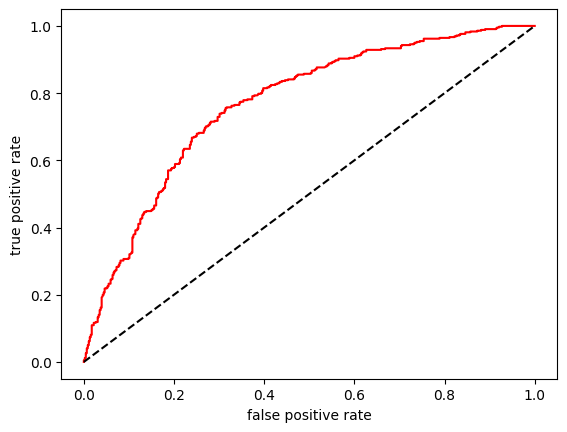

In [22]:
probablities = logistic_model.predict_proba (X_train) [:,1]

fpr, tpr, thresholds = roc_curve(y_train, probablities)

auc = roc_auc_score(y_train,probablities)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color = "red", label = "logit model ( area = %0.2f)" %auc)
plt.plot([0,1],[0,1],"k--")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")

In [23]:
accuracy_score(y_train,y_predicted_train)

0.7111872146118722

### 8.2 test data's evaluation metrics - test accuracy

In [24]:
accuracy_score(y_test,y_predicted_test)

0.6818181818181818

In [25]:
print(confusion_matrix(y_test,y_predicted_test))

[[78 45]
 [25 72]]


0.7377420165954236


Text(0, 0.5, 'true positive rate')

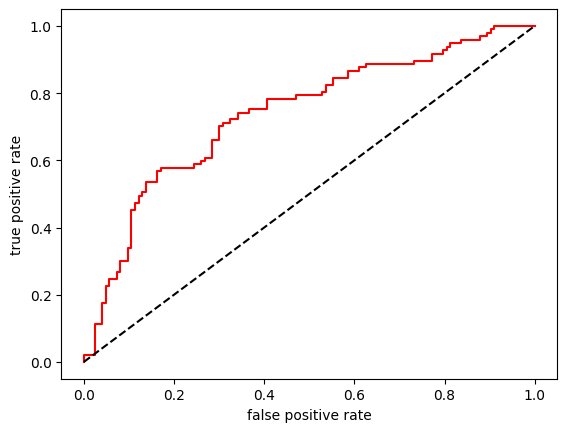

In [27]:
test_probablities = logistic_model.predict_proba (X_test) [:,1]

fpr, tpr, thresholds = roc_curve(y_test, test_probablities)

auc = roc_auc_score(y_test,test_probablities)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color = "red", label = "logit model ( area = %0.2f)" %auc)
plt.plot([0,1],[0,1],"k--")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")

## 9. MODEL DEPLOYMENT

In [28]:
from pickle import dump

In [29]:
dump(obj = logistic_model, file = open(file = "claimants1.pkl", mode='wb'))

In [30]:
from pickle import load

In [31]:
claimants_intel_file = load(file = open(file = "claimants1.pkl", mode='rb'))

## end